## Configuración e importación de librerías

Carga y manipulación de datos

In [20]:

import pandas as pd
import geopandas as gpd
import numpy as np
import os
import re
import shutil
from datetime import datetime
from pathlib import Path
import io
import time

Datos espaciales - vectores

In [21]:
from shapely.geometry import Point
import geopandas as gpd

Datos espaciales - raster y análisis espacial

In [22]:
import rasterio
from rasterio.merge import merge
import rioxarray
import xarray as xr
import xrspatial as xrs

Modelado y aprendizaje automático

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (accuracy_score, f1_score, recall_score, precision_score, 
                             roc_auc_score, confusion_matrix, classification_report, roc_curve)

Evaluación del modelo

In [24]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

Visualización

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import PathPatch
import matplotlib.path as mpath
import contextily as cx

Herramientas científicas y soporte

In [26]:
from scipy.interpolate import griddata


Serialización y persistencia

In [27]:
import pickle

Fijar semillas aleatorias para reproducibilidad

In [28]:
seed = 42
np.random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)

Rutas a la carpetas de datos

In [29]:
DATA_DIR = Path("data")
DEM_DIR = DATA_DIR / "DEM"
FIRMS_DIR = DATA_DIR / "FIRMS" 
COBERTURA_DIR = DATA_DIR / "Cobertura_del_Suelo"
NDVI_DIR = DATA_DIR / "NDVI" 

try:
    HUMEDAD_CSV_PATH = list((DATA_DIR / "Humedad").glob("*.csv"))[0]
    PRECIPITATION_CSV_PATH = list((DATA_DIR / "Precipitation").glob("*.csv"))[0]
    TEMPERATURE_CSV_PATH = list((DATA_DIR / "Temperature").glob("*.csv"))[0]
    WIND_CSV_PATH = list((DATA_DIR / "Wind").glob("*.csv"))[0]
    print("Rutas a los archivos CSV climáticos encontradas exitosamente.")
except IndexError:
    print("ERROR CRÍTICO: No se encontró un archivo CSV en una de las carpetas climáticas. Revisa las carpetas.")
    exit() 

MERGED_DEM_PATH = DEM_DIR / "DEM_Cordillera.tif"
DEPARTAMENTO_SHP_PATH = DATA_DIR / "COORDILLERA" / "Departamento_Coordillera.shp"
VIAS_SHP_PATH = DATA_DIR / "COORDILLERA" / "Vias_principales_Coordillera.shp"
CIUDADES_SHP_PATH = DATA_DIR / "COORDILLERA" / "Ciudades_Coordillera.shp"
DISTRITOS_SHP_PATH = DATA_DIR / "COORDILLERA" / "Distritos_Coordillera.shp"

TIMESTAMP = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
OUTPUT_DIR = Path("outputs") / TIMESTAMP
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Los resultados se guardarán en: {OUTPUT_DIR}")

Rutas a los archivos CSV climáticos encontradas exitosamente.
Los resultados se guardarán en: outputs\2026-02-15_19-19-00


## Funciones auxiliares

In [30]:
def load_firms_data(firms_folder, study_area_geom, crs):
    print("Cargando y FILTRANDO datos de focos de calor (FIRMS)...")
    firms_files = list(firms_folder.glob("**/*.csv"))
    if not firms_files: raise FileNotFoundError("No se encontraron archivos .csv")
    firms_df = pd.concat([pd.read_csv(f) for f in firms_files if 'focos_cordillera' not in f.name], ignore_index=True)
    total_inicial = len(firms_df)
    # --- FILTRO 1: TIPO DE INCENDIO (Solo vegetación) ---
    if 'type' in firms_df.columns:
        firms_df = firms_df[firms_df['type'] == 0]
    # --- FILTRO 2: CONFIANZA ---
    if 'confidence' in firms_df.columns:
        if firms_df['confidence'].dtype == 'object':
            firms_df = firms_df[firms_df['confidence'].isin(['n', 'h'])]
        else:
            firms_df = firms_df[firms_df['confidence'] >= 30]

    print(f"Filtro de calidad: Se eliminaron {total_inicial - len(firms_df)} falsos positivos o industriales.")

    firms_df['date'] = pd.to_datetime(firms_df['acq_date'])
    gdf_incendios = gpd.GeoDataFrame(firms_df, geometry=gpd.points_from_xy(firms_df.longitude, firms_df.latitude), crs="EPSG:4326").to_crs(crs)
    
    # Filtro espacial
    gdf_incendios = gdf_incendios[gdf_incendios.within(study_area_geom)]
    gdf_incendios['fire'] = 1
    
    print(f"Se cargaron {len(gdf_incendios)} puntos de incendios validados.")
    return gdf_incendios[['date', 'geometry', 'fire']]

def load_climate_data(temp_path, precip_path, wind_path, humidity_path):
    print("Cargando y combinando datos climáticos diarios...")
    temp_df = pd.read_csv(temp_path)[['datetime', 'temp_C']].rename(columns={'temp_C': 'temperature'})
    precip_df = pd.read_csv(precip_path)[['datetime', 'precip_mm']].rename(columns={'precip_mm': 'precipitation'})
    wind_df = pd.read_csv(wind_path)[['datetime', 'wind_speed_10m']].rename(columns={'wind_speed_10m': 'wind_speed'})
    hum_df = pd.read_csv(humidity_path)[['date', 'mean_RH']].rename(columns={'mean_RH': 'humidity'})
    
    for df in [temp_df, precip_df, wind_df, hum_df]:
        df['datetime'] = pd.to_datetime(df.get('datetime', df.get('date')))
    
    climate_dfs = [temp_df, precip_df, wind_df]
    weather_df = climate_dfs[0]
    for df_to_merge in climate_dfs[1:]: weather_df = pd.merge(weather_df, df_to_merge, on='datetime', how='outer')
    
    weather_df = weather_df.set_index('datetime')
    daily_weather = weather_df.resample('D').agg({'temperature': 'mean', 'precipitation': 'sum', 'wind_speed': 'mean'}).reset_index()
    final_weather_df = pd.merge(daily_weather, hum_df, on='datetime', how='outer').set_index('datetime').sort_index().ffill().bfill()
    print("Datos climáticos diarios cargados y combinados exitosamente.")
    return final_weather_df

def asignar_variables(df_puntos, dem_path, cobertura_folder, ndvi_mensual_folder, weather_df, vias_shp_path, ciudades_shp_path):
    """
    Asigna TODAS las variables predictoras
    """
    print("\n--- INICIANDO FASE DE ASIGNACIÓN DE VARIABLES ---")
    if df_puntos.empty: return df_puntos
    
    dataset = df_puntos.copy()
    dataset['year'] = dataset['date'].dt.year
    dataset['month'] = dataset['date'].dt.month
    
    # --- 3.1. Variables Topográficas ---
    print("Asignando variables topográficas...")
    # Abrimos el DEM original en su CRS geográfico (EPSG:4674)
    dem_geo = rioxarray.open_rasterio(dem_path).squeeze()
    
    # Extraemos la elevación del DEM original, ya que nuestros puntos están en ese CRS
    x_coords = xr.DataArray(dataset.geometry.x, dims="points")
    y_coords = xr.DataArray(dataset.geometry.y, dims="points")
    dataset['elevacion'] = dem_geo.sel(x=x_coords, y=y_coords, method="nearest").values
    
    # --- CORRECCIÓN CLAVE ---
    # Reproyectamos el DEM a un CRS en metros (UTM) SOLO para calcular pendiente y orientación
    print("Reproyectando DEM para cálculo de pendiente/orientación...")
    dem_utm = dem_geo.rio.reproject("EPSG:31981")
    
    # Calculamos pendiente y orientación sobre el DEM en metros
    slope_utm = xrs.slope(dem_utm)
    aspect_utm = xrs.aspect(dem_utm)
    
    # Para extraer los valores, necesitamos las coordenadas de nuestros puntos en el nuevo CRS (UTM)
    dataset_utm = dataset.to_crs("EPSG:31981")
    x_coords_utm = xr.DataArray(dataset_utm.geometry.x, dims="points")
    y_coords_utm = xr.DataArray(dataset_utm.geometry.y, dims="points")
    
    # Extraemos los valores de pendiente y orientación
    dataset['pendiente'] = slope_utm.sel(x=x_coords_utm, y=y_coords_utm, method="nearest").values
    dataset['orientacion'] = aspect_utm.sel(x=x_coords_utm, y=y_coords_utm, method="nearest").values

    # El resto del código de esta sección no cambia
    bins = [-1, 22.5, 67.5, 112.5, 157.5, 202.5, 247.5, 292.5, 337.5, 361]; labels = ["N", "NE", "E", "SE", "S", "SW", "W", "NW", "N"]
    dataset['orientacion_cat'] = pd.cut(dataset['orientacion'], bins=bins, labels=labels, right=False, ordered=False).cat.add_categories("Plano").fillna("Plano")

    # --- El resto de la función (Cobertura, NDVI, Clima, Proximidad) permanece idéntico ---
    print("Asignando Cobertura del Suelo por año...")
    dataset['cobertura'] = np.nan
    for year in sorted(dataset['year'].unique()):
        cobertura_path = cobertura_folder / f"Cobertura_Cordillera_{year}.tif"
        if cobertura_path.exists():
            cobertura_raster = rioxarray.open_rasterio(cobertura_path, masked=True).squeeze(drop=True)
            idx_year = dataset['year'] == year
            if idx_year.any():
                group_year_proj = dataset.loc[idx_year].to_crs(cobertura_raster.rio.crs)
                x_coords_year = xr.DataArray(group_year_proj.geometry.x, dims="points")
                y_coords_year = xr.DataArray(group_year_proj.geometry.y, dims="points")
                dataset.loc[idx_year, 'cobertura'] = cobertura_raster.sel(x=x_coords_year, y=y_coords_year, method="nearest").values

    print("Asignando NDVI desde archivos mensuales...")
    dataset['ndvi'] = np.nan
    NDVI_SCALE_FACTOR = 0.0001
    ndvi_files_map = { (int(f.stem.split('_')[2]), int(f.stem.split('_')[3])): f 
                       for f in ndvi_mensual_folder.glob("NDVI_MODIS_*.tif") }
    
    for (year, month), group in dataset.groupby(['year', 'month']):
        if (year, month) in ndvi_files_map:
            raster_path = ndvi_files_map[(year, month)]
            raster = rioxarray.open_rasterio(raster_path, masked=True).squeeze(drop=True)
            group_proj = group.to_crs(raster.rio.crs)
            x_coords_group = xr.DataArray(group_proj.geometry.x, dims="points")
            y_coords_group = xr.DataArray(group_proj.geometry.y, dims="points")
            raw_values = raster.sel(x=x_coords_group, y=y_coords_group, method="nearest").values
            scaled_values = np.where(~np.isnan(raw_values), raw_values * NDVI_SCALE_FACTOR, np.nan)
            dataset.loc[group.index, 'ndvi'] = scaled_values

    print("Asignando variables meteorológicas...")
    dataset = dataset.sort_values('date')
    dataset = pd.merge_asof(dataset, weather_df, left_on='date', right_index=True, direction='backward')
    
    print("Añadiendo características de proximidad...")
    projected_crs = "EPSG:31981"
    dataset_proj = dataset.to_crs(projected_crs)
    vias_gdf = gpd.read_file(VIAS_SHP_PATH).to_crs(projected_crs)
    ciudades_gdf = gpd.read_file(CIUDADES_SHP_PATH).to_crs(projected_crs)
    dataset['dist_vias'] = dataset_proj.geometry.distance(vias_gdf.union_all())
    dataset['dist_ciudades'] = dataset_proj.geometry.distance(ciudades_gdf.union_all())

    print("Asignación de variables completada.")
    return dataset

## Generación de la muestra y asignación de datos

In [31]:
print("\n--- INICIANDO FASE DE PREPARACIÓN DE DATOS ---")
area_estudio_gdf = gpd.read_file(DEPARTAMENTO_SHP_PATH)
CRS_REFERENCE = area_estudio_gdf.crs.to_string()
study_area_bounds = area_estudio_gdf.total_bounds
study_area_polygon = area_estudio_gdf.union_all()
print("\nCreando máscara de zonas inflamables a partir de la Cobertura del Suelo...")

# Define la ruta a solo UNO de tus archivos de cobertura, el más reciente servirá.
# Necesitamos la estructura, no los valores anuales.
COBERTURA_PATH_BASE = COBERTURA_DIR / "Cobertura_Cordillera_2023.tif" # O el año que sea

# Define las clases de cobertura que consideras "inflamables"
CLASES_INFLAMABLES = [3.0, 6.0, 11.0, 12.0, 15.0]  # <-- ¡¡¡AJUSTA ESTOS VALORES!!! Son los que identificaste en QGIS.

# Carga el raster
with rasterio.open(COBERTURA_PATH_BASE) as src:
    # Lee el raster como un array de numpy
    cobertura_array = src.read(1)
    transform = src.transform
    crs = src.crs

    # Crea una máscara booleana: True donde la clase es inflamable
    mask = np.isin(cobertura_array, CLASES_INFLAMABLES)

    # Vectoriza el raster: convierte los píxeles True en polígonos
    # Esto crea una lista de (geometría, valor) para cada polígono de píxeles conectados
    shapes = list(rasterio.features.shapes(mask.astype('uint8'), mask=mask, transform=transform))

shapes_geojson = [{'geometry': geom, 'properties': {'value': val}} for geom, val in shapes]
# 2. Ahora creamos el GeoDataFrame desde esta lista bien formateada
zonas_inflamables_gdf = gpd.GeoDataFrame.from_features(shapes_geojson, crs=crs)

# 3. La disolución funciona igual que antes
zonas_inflamables_poligono = zonas_inflamables_gdf.unary_union

print("Máscara de zonas inflamables creada exitosamente.")
print(f"Área de estudio definida. CRS: {CRS_REFERENCE}")

puntos_positivos = load_firms_data(FIRMS_DIR, study_area_polygon, CRS_REFERENCE)

print("\nGenerando muestras negativas (no-incendios) con muestreo de fondo inteligente...")
n_negativos = len(puntos_positivos) if len(puntos_positivos) > 0 else 1000
puntos_negativos_list = []
minx, miny, maxx, maxy = study_area_bounds
start_date, end_date = puntos_positivos['date'].min(), puntos_positivos['date'].max()
dias_rango = (end_date - start_date).days
projected_crs = "EPSG:31981"
puntos_positivos_proj = puntos_positivos.to_crs(projected_crs)
incendios_por_dia_proj = {d: g[['geometry']] for d, g in puntos_positivos_proj.groupby(puntos_positivos_proj['date'].dt.date)}
intentos = 0
max_intentos = n_negativos * 500 # Aumentamos los intentos porque será más difícil encontrar puntos

while len(puntos_negativos_list) < n_negativos:
    intentos += 1
    if intentos > max_intentos:
        print(f"\nADVERTENCIA: Se superó el número máximo de intentos ({max_intentos}). Se generaron {len(puntos_negativos_list)} puntos.")
        break
    
    # 1. Generar un punto aleatorio dentro de los límites del departamento
    random_point_geo = Point(np.random.uniform(minx, maxx), np.random.uniform(miny, maxy))
    
    # 2. PRIMER FILTRO: ¿Está el punto dentro del área de estudio Y dentro de una zona inflamable?
    #    Usamos 'within' que es más rápido que la comprobación de cobertura del raster.
    if not random_point_geo.within(zonas_inflamables_poligono):
        continue  # Si no está en una zona inflamable, se descarta y se prueba de nuevo.

    # 3. Si pasa el primer filtro, se procede a la comprobación de proximidad a incendios
    random_date = start_date + pd.to_timedelta(np.random.randint(0, dias_rango + 1), unit='d')
    es_valido = True
    ventana_temporal_dias = 3
    distancia_min_metros = 15000

    # Proyectar el punto aleatorio a UTM para el cálculo de distancia
    # Hacemos esto solo para los puntos que ya son candidatos, es más eficiente.
    random_point_gds_proj = gpd.GeoSeries([random_point_geo], crs=CRS_REFERENCE).to_crs(projected_crs)

    for i in range(-ventana_temporal_dias, ventana_temporal_dias + 1):
        check_date = (random_date + pd.to_timedelta(i, unit='d')).date()
        if check_date in incendios_por_dia_proj:
            if incendios_por_dia_proj[check_date].distance(random_point_gds_proj.iloc[0]).min() < distancia_min_metros:
                es_valido = False
                break
    
    # 4. Si el punto es válido en ambos filtros, se añade a la lista
    if es_valido:
        puntos_negativos_list.append({'date': random_date, 'geometry': random_point_geo, 'fire': 0})
        if len(puntos_negativos_list) % 200 == 0:
            print(f"  ... {len(puntos_negativos_list)}/{n_negativos} puntos negativos generados. (Tasa de éxito: {len(puntos_negativos_list)/intentos:.2%})")
if not puntos_negativos_list:
    print("\nERROR CRÍTICO: No se pudo generar ningún punto negativo.")
    exit()

puntos_negativos = gpd.GeoDataFrame(puntos_negativos_list, crs=CRS_REFERENCE)
sample = pd.concat([puntos_positivos, puntos_negativos], ignore_index=True).sample(frac=1, random_state=seed).reset_index(drop=True)
print(f"\nMuestra final generada con {len(sample)} observaciones.")

weather_data = load_climate_data(TEMPERATURE_CSV_PATH, PRECIPITATION_CSV_PATH, WIND_CSV_PATH, HUMEDAD_CSV_PATH)
full_dataset = asignar_variables(sample, MERGED_DEM_PATH, COBERTURA_DIR, NDVI_DIR, weather_data, VIAS_SHP_PATH, CIUDADES_SHP_PATH)



--- INICIANDO FASE DE PREPARACIÓN DE DATOS ---

Creando máscara de zonas inflamables a partir de la Cobertura del Suelo...


C:\Users\usuario\AppData\Local\Temp\ipykernel_2256\2473378066.py:34: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  zonas_inflamables_poligono = zonas_inflamables_gdf.unary_union


Máscara de zonas inflamables creada exitosamente.
Área de estudio definida. CRS: EPSG:4674
Cargando y FILTRANDO datos de focos de calor (FIRMS)...
Filtro de calidad: Se eliminaron 2937 falsos positivos o industriales.
Se cargaron 12551 puntos de incendios validados.

Generando muestras negativas (no-incendios) con muestreo de fondo inteligente...
  ... 200/12551 puntos negativos generados. (Tasa de éxito: 24.94%)
  ... 400/12551 puntos negativos generados. (Tasa de éxito: 23.95%)
  ... 600/12551 puntos negativos generados. (Tasa de éxito: 22.74%)
  ... 800/12551 puntos negativos generados. (Tasa de éxito: 22.67%)
  ... 1000/12551 puntos negativos generados. (Tasa de éxito: 22.76%)
  ... 1200/12551 puntos negativos generados. (Tasa de éxito: 22.81%)
  ... 1400/12551 puntos negativos generados. (Tasa de éxito: 22.58%)
  ... 1600/12551 puntos negativos generados. (Tasa de éxito: 22.46%)
  ... 1800/12551 puntos negativos generados. (Tasa de éxito: 22.36%)
  ... 2000/12551 puntos negativos 

## Depuración y modelado

In [32]:
print("\n--- INICIANDO FASE DE DEPURACIÓN ---")
print("Valores nulos por columna ANTES de depurar:\n", full_dataset.isnull().sum())
datos_depurados = full_dataset.dropna()
print(f"\nRegistros ANTES de depurar: {len(full_dataset)} | DESPUÉS de depurar: {len(datos_depurados)}")

if len(datos_depurados) < 100:
    print("\nERROR CRÍTICO: No hay suficientes datos después de la depuración.")
    exit()

columnas_modelo = ['elevacion', 'pendiente', 'orientacion_cat', 'cobertura', 'ndvi', 'temperature', 'precipitation', 'wind_speed', 'humidity', 'dist_vias', 'dist_ciudades', 'fire']
datos_modelo = datos_depurados[columnas_modelo].copy()
datos_modelo['cobertura'] = datos_modelo['cobertura'].astype('category')
print("\nInfo del dataset final:\n"); datos_modelo.info()
print("\nVista previa del dataset final:\n", datos_modelo.head())
buffer = io.StringIO()
datos_modelo.info(buf=buffer)
info_string = buffer.getvalue()
head_string = datos_modelo.head().to_string()
ruta_resumen_dataset = OUTPUT_DIR / "dataset_summary.txt"
with open(ruta_resumen_dataset, "w") as f:
    f.write("=========================================\n")
    f.write(" RESUMEN DEL DATASET FINAL (datos_modelo)\n")
    f.write("=========================================\n\n")
    f.write("--- DataFrame .info() ---\n")
    f.write(info_string)
    f.write("\n\n--- DataFrame .head() ---\n")
    f.write(head_string)
    f.write("\n")
print(f"Resumen del dataset guardado en: {ruta_resumen_dataset}")



--- INICIANDO FASE DE DEPURACIÓN ---
Valores nulos por columna ANTES de depurar:
 date               0
date_x             0
geometry           0
fire               0
year               0
month              0
elevacion          0
pendiente          0
orientacion        0
orientacion_cat    0
cobertura          0
ndvi               0
temperature        0
precipitation      0
wind_speed         0
date_y             0
humidity           0
dist_vias          0
dist_ciudades      0
dtype: int64

Registros ANTES de depurar: 25102 | DESPUÉS de depurar: 25102

Info del dataset final:

<class 'pandas.core.frame.DataFrame'>
Index: 25102 entries, 15532 to 14417
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   elevacion        25102 non-null  int16   
 1   pendiente        25102 non-null  float32 
 2   orientacion_cat  25102 non-null  category
 3   cobertura        25102 non-null  category
 4   ndvi             2510

## Modelado con validación temporal

In [33]:
print("\n--- INICIANDO FASE DE MODELADO CON VALIDACIÓN TEMPORAL ---")

# 1. Recuperamos el año de 'datos_depurados' (ya que en datos_modelo no lo incluimos)
# Usamos el índice de datos_modelo para asegurar que coincidan tras la depuración
datos_modelo['anio'] = datos_depurados.loc[datos_modelo.index, 'date'].dt.year

# 2. Definición de los bloques temporales (80% / 20% aprox)
# Entrenamiento: 2018, 2019, 2020, 2021, 2022
# Prueba: 2023
train_df = datos_modelo[datos_modelo['anio'] <= 2022].copy()
test_df = datos_modelo[datos_modelo['anio'] == 2023].copy()

# 3. Guardamos los años para posibles análisis de errores después, pero los quitamos del entrenamiento
anios_test = test_df['anio']
train_df = train_df.drop(columns=['anio'])
test_df = test_df.drop(columns=['anio'])

print(f"División TEMPORAL:")
print(f"  - Entrenamiento (2018-2022): {len(train_df)} muestras")
print(f"  - Prueba (2023): {len(test_df)} muestras")

# 4. Verificación de balance de clases
for df_name, df in [("Entrenamiento", train_df), ("Prueba", test_df)]:
    conteo = df['fire'].value_counts()
    print(f"Balance en {df_name}: Incendios={conteo.get(1, 0)}, No-incendios={conteo.get(0, 0)}")

# 5. Comprobar que ambas clases están presentes
if train_df['fire'].nunique() < 2 or test_df['fire'].nunique() < 2:
    print("\nERROR: Uno de los periodos no tiene suficientes ejemplos de incendios o no-incendios.")
else:
    X_train = train_df.drop('fire', axis=1)
    y_train = train_df['fire']
    X_test = test_df.drop('fire', axis=1)
    y_test = test_df['fire']
    
    # --- 5.2. Pipeline de preprocesamiento (sin cambios) ---
    numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
    categorical_features = X_train.select_dtypes(include=['category', 'object']).columns.tolist()
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numeric_features),
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
        ], remainder='drop')

    from sklearn.naive_bayes import GaussianNB
    from sklearn.neural_network import MLPClassifier
    from sklearn.ensemble import StackingClassifier
    
    # Intentamos importar las librerías de Boosting (si fallan, avisa)
    try:
        from xgboost import XGBClassifier
        from lightgbm import LGBMClassifier
        from catboost import CatBoostClassifier
    except ImportError:
        print("ERROR CRÍTICO: Faltan librerías. Ejecuta: pip install xgboost lightgbm catboost")
        raise

    # 2. Definición del Nivel 0 (9 Modelos Base)
    level_0_estimators = [
        ('rf', RandomForestClassifier(n_estimators=100, min_samples_leaf=2, n_jobs=-1, random_state=seed)),
        ('xgb', XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=4, eval_metric='logloss', n_jobs=-1, random_state=seed)),
        ('lgbm', LGBMClassifier(n_estimators=100, learning_rate=0.1, num_leaves=31, n_jobs=-1, random_state=seed, verbose=-1)),
        ('svm', CalibratedClassifierCV(LinearSVC(dual='auto', random_state=seed), cv=3)),
        ('knn', KNeighborsClassifier(n_neighbors=15, n_jobs=-1)),
        ('cat', CatBoostClassifier(iterations=100, learning_rate=0.1, depth=4, verbose=0, random_state=seed)),
        ('mlp', MLPClassifier(hidden_layer_sizes=(50, 25), activation='relu', alpha=0.001, max_iter=500, early_stopping=True, random_state=seed))
    ]

    # 3. Definición del Nivel 1 (Meta-Modelo)
    level_1_meta_model = LogisticRegression(solver='lbfgs', C=1.0, random_state=seed)

    # 4. Creación del Stacking Classifier
    stacking_model = StackingClassifier(
        estimators=level_0_estimators,
        final_estimator=level_1_meta_model,
        cv=5,
        stack_method='predict_proba',
        n_jobs=-1,
        passthrough=False 
    )

    # 5. Pipeline Final
    full_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', stacking_model)])
    # --- 5.4. Entrenar y Evaluar ---
    print("\nEntrenando el modelo de Stacking...")
    full_pipeline.fit(X_train, y_train)
    print("Entrenamiento completado.")




--- INICIANDO FASE DE MODELADO CON VALIDACIÓN TEMPORAL ---
División TEMPORAL:
  - Entrenamiento (2018-2022): 21160 muestras
  - Prueba (2023): 3942 muestras
Balance en Entrenamiento: Incendios=10628, No-incendios=10532
Balance en Prueba: Incendios=1923, No-incendios=2019

Entrenando el modelo de Stacking...
Entrenamiento completado.


### EVALUACIÓN UNIFICADA (MÉTRICAS + TIEMPO + MEMORIA)

In [34]:


print("\n--- RECOPILANDO MÉTRICAS PARA TOPSIS Y COMPARATIVA ---")

# Preparamos los datos transformados para los modelos base (para ser justos)
X_test_trans = full_pipeline.named_steps['preprocessor'].transform(X_test)
stacking_clf = full_pipeline.named_steps['classifier']

# Diccionario con todos los modelos
modelos_a_evaluar = {name.upper(): model for name, model in stacking_clf.named_estimators_.items()}
modelos_a_evaluar['STACKING'] = full_pipeline # El pipeline completo usa X_test sin transformar

resultados_globales = []

for nombre, modelo in modelos_a_evaluar.items():
    print(f"Evaluando: {nombre}...")
    
    # 1. Medir Tiempo de Inferencia y Predicción
    start_time = time.time()
    
    if nombre == 'STACKING':
        y_pred = modelo.predict(X_test)
        y_proba = modelo.predict_proba(X_test)[:, 1]
    else:
        y_pred = modelo.predict(X_test_trans)
        if hasattr(modelo, "predict_proba"):
            y_proba = modelo.predict_proba(X_test_trans)[:, 1]
        else:
            # Fallback para modelos como SVM (si no estuviera calibrado)
            d = modelo.decision_function(X_test_trans)
            y_proba = (d - d.min()) / (d.max() - d.min())
            
    end_time = time.time()
    tiempo_segundos = end_time - start_time
    
    # 2. Calcular Métricas de Clasificación
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_proba)
    
    # Specificity (TN / (TN + FP))
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    # 3. Medir Memoria (Estimación serialización)
    try:
        peso_mb = len(pickle.dumps(modelo)) / (1024 * 1024)
    except:
        peso_mb = 0

    resultados_globales.append({
        'Modelo': nombre,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1_Score': f1,
        'ROC_AUC': auc,
        'Specificity': spec,
        'Tiempo_Inferencia': tiempo_segundos,
        'Memoria_MB': peso_mb,
        'y_proba': y_proba # Guardamos para graficar luego
    })

df_resultados = pd.DataFrame(resultados_globales).set_index('Modelo')
print("Evaluación completada.")


--- RECOPILANDO MÉTRICAS PARA TOPSIS Y COMPARATIVA ---
Evaluando: RF...
Evaluando: XGB...
Evaluando: LGBM...


f:\FPUNA-SEMESTRES\extras_cosas\tesis\pruebas\stacking-ML-prueba\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
f:\FPUNA-SEMESTRES\extras_cosas\tesis\pruebas\stacking-ML-prueba\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Evaluando: SVM...
Evaluando: KNN...
Evaluando: CAT...
Evaluando: MLP...
Evaluando: STACKING...


f:\FPUNA-SEMESTRES\extras_cosas\tesis\pruebas\stacking-ML-prueba\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
f:\FPUNA-SEMESTRES\extras_cosas\tesis\pruebas\stacking-ML-prueba\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Evaluación completada.


### Implementación de Metodología AHP/Experto + TOPSIS

In [35]:
print("\n--- 4. ANÁLISIS MULTICRITERIO: AHP + TOPSIS ---")

# -------------------------------------------------------------------------
# PASO 1: CÁLCULO FORMAL DE PESOS MEDIANTE AHP (MATRIZ DE SAATY)
# -------------------------------------------------------------------------

# Definimos los criterios en el orden exacto de las columnas de TOPSIS
criterios_orden = ['Accuracy', 'Precision', 'Recall', 'F1_Score', 'ROC_AUC', 'Specificity', 'Tiempo_Inferencia', 'Memoria_MB']
n = len(criterios_orden)

# Matriz de comparación por pares (A) basada en juicios de experto
# Basada en tu matriz previa, ajustada para priorizar Recall y F1.
A = np.array([
# Acc    Prec   Rec    F1     AUC    Spec   Time   Mem
[ 1,     1/2,   1/5,   1/4,   1/3,   1/2,   5,     5],   # Accuracy
[ 2,     1,     1/4,   1/3,   1/2,   1,     5,     5],   # Precision
[ 5,     4,     1,     3,     3,     4,     7,     7],   # Recall
[ 4,     3,     1/3,   1,     2,     3,     6,     6],   # F1
[ 3,     2,     1/3,   1/2,   1,     2,     6,     6],   # AUC
[ 2,     1,     1/4,   1/3,   1/2,   1,     5,     5],   # Specificity
[ 1/5,   1/5,   1/7,   1/6,   1/6,   1/5,   1,     1],   # Tiempo
[ 1/5,   1/5,   1/7,   1/6,   1/6,   1/5,   1,     1]    # Memoria
])

# Cálculo del Vector Propio (Pesos AHP)
eigenvalues, eigenvectors = np.linalg.eig(A)
max_index = np.argmax(eigenvalues.real)
lambda_max = eigenvalues.real[max_index]
weights_ahp = eigenvectors[:, max_index].real
weights_ahp = weights_ahp / weights_ahp.sum() # Normalizar para que sumen 1

# Verificación de Consistencia (CR)
CI = (lambda_max - n) / (n - 1)
RI_dict = {1: 0, 2: 0, 3: 0.58, 4: 0.9, 5: 1.12, 6: 1.24, 7: 1.32, 8: 1.41}
CR = CI / RI_dict[n]

print(f">>> Validación AHP: Ratio de Consistencia (CR) = {CR:.4f}")
if CR < 0.1:
    print(">>> La matriz es CONSISTENTE académicamente.")
else:
    print(">>> ADVERTENCIA: La matriz requiere revisión de juicios (CR >= 0.1).")

# -------------------------------------------------------------------------
# PASO 2: CREACIÓN DE TABLA DE JUSTIFICACIÓN DINÁMICA
# -------------------------------------------------------------------------

prioridades = []
for w in weights_ahp:
    if w > 0.25: p = "Muy Alta (Crítica)"
    elif w > 0.15: p = "Alta"
    elif w > 0.05: p = "Media"
    else: p = "Baja / Referencial"
    prioridades.append(p)

justificaciones = [
    "Referencial de rendimiento global.",
    "Importante para reducir falsas alarmas.",
    "CRÍTICO: Prioridad máxima para no omitir incendios reales.",
    "Balance robusto entre precisión y sensibilidad.",
    "Capacidad de discriminación global del modelo.",
    "Capacidad para descartar correctamente zonas seguras.",
    "Criterio de eficiencia (costo). Impacto marginal en el riesgo.",
    "Criterio de eficiencia (costo). Hardware actual es suficiente."
]

df_ahp_final = pd.DataFrame({
    "Criterio": criterios_orden,
    "Peso (AHP)": weights_ahp,
    "Prioridad": prioridades,
    "Justificación Científica": justificaciones
})

display(df_ahp_final.style.format({"Peso (AHP)": "{:.4f}"}).hide(axis="index"))

# -------------------------------------------------------------------------
# PASO 3: ALGORITMO TOPSIS USANDO LOS PESOS DE AHP
# -------------------------------------------------------------------------

X_matriz = df_resultados[criterios_orden].copy()

# Transformación Logarítmica para criterios de costo (Tiempo y Memoria)
X_matriz['Tiempo_Inferencia'] = np.log1p(X_matriz['Tiempo_Inferencia'])
X_matriz['Memoria_MB'] = np.log1p(X_matriz['Memoria_MB'])

# 1 = Beneficio, -1 = Costo
criteria_types = np.array([1, 1, 1, 1, 1, 1, -1, -1])

# Normalización Vectorial
X_norm = X_matriz / np.sqrt((X_matriz**2).sum())

# Asignar los pesos calculados por AHP
V = X_norm * weights_ahp

# Determinar Soluciones Ideales (Positiva y Negativa)
ideal_pos = [V[col].max() if criteria_types[i] == 1 else V[col].min() for i, col in enumerate(criterios_orden)]
ideal_neg = [V[col].min() if criteria_types[i] == 1 else V[col].max() for i, col in enumerate(criterios_orden)]

# Calcular Distancias Euclidianas
dist_pos = np.sqrt(((V - ideal_pos) ** 2).sum(axis=1))
dist_neg = np.sqrt(((V - ideal_neg) ** 2).sum(axis=1))

# Score TOPSIS (Cercanía relativa al ideal)
topsis_score = dist_neg / (dist_pos + dist_neg)

# -------------------------------------------------------------------------
# PASO 4: RANKING FINAL
# -------------------------------------------------------------------------
df_ranking = df_resultados[criterios_orden].copy()
df_ranking['TOPSIS_Score'] = topsis_score
df_ranking['Rank'] = df_ranking['TOPSIS_Score'].rank(ascending=False).astype(int)
df_ranking = df_ranking.sort_values('Rank')

print("\n=== RANKING FINAL DE MODELOS (BASADO EN AHP-TOPSIS) ===")
display(df_ranking.style.background_gradient(cmap='RdYlGn', subset=['TOPSIS_Score', 'Recall']))


--- 4. ANÁLISIS MULTICRITERIO: AHP + TOPSIS ---
>>> Validación AHP: Ratio de Consistencia (CR) = 0.0450
>>> La matriz es CONSISTENTE académicamente.


Criterio,Peso (AHP),Prioridad,Justificación Científica
Accuracy,0.0685,Media,Referencial de rendimiento global.
Precision,0.0948,Media,Importante para reducir falsas alarmas.
Recall,0.3374,Muy Alta (Crítica),CRÍTICO: Prioridad máxima para no omitir incendios reales.
F1_Score,0.2077,Alta,Balance robusto entre precisión y sensibilidad.
ROC_AUC,0.1474,Media,Capacidad de discriminación global del modelo.
Specificity,0.0948,Media,Capacidad para descartar correctamente zonas seguras.
Tiempo_Inferencia,0.0247,Baja / Referencial,Criterio de eficiencia (costo). Impacto marginal en el riesgo.
Memoria_MB,0.0247,Baja / Referencial,Criterio de eficiencia (costo). Hardware actual es suficiente.



=== RANKING FINAL DE MODELOS (BASADO EN AHP-TOPSIS) ===


,Accuracy,Precision,Recall,F1_Score,ROC_AUC,Specificity,Tiempo_Inferencia,Memoria_MB,TOPSIS_Score,Rank
Modelo,,,,,,,,,,
CAT,0.818620,0.886684,0.720229,0.794835,0.916089,0.912333,0.173002,0.039907,0.880568,1
MLP,0.811263,0.882544,0.707228,0.785219,0.907063,0.910352,0.034005,0.068736,0.844630,2
LGBM,0.827245,0.920732,0.706708,0.799647,0.916217,0.942051,0.277004,0.332776,0.807506,3
SVM,0.799340,0.876330,0.685387,0.769186,0.910737,0.907875,0.021005,0.002432,0.745148,4
XGB,0.830036,0.906027,0.726989,0.806694,0.916287,0.928182,0.756994,0.155578,0.707771,5
RF,0.809488,0.888079,0.697348,0.781241,0.904155,0.916295,0.208010,24.146306,0.460121,6
KNN,0.806190,0.869344,0.709308,0.781214,0.891755,0.898465,1.615528,4.359516,0.365015,7
STACKING,0.812532,0.881935,0.710868,0.787216,0.914562,0.909361,2.117074,29.114799,0.167210,8


### VISUALIZACIÓN DE RESULTADOS

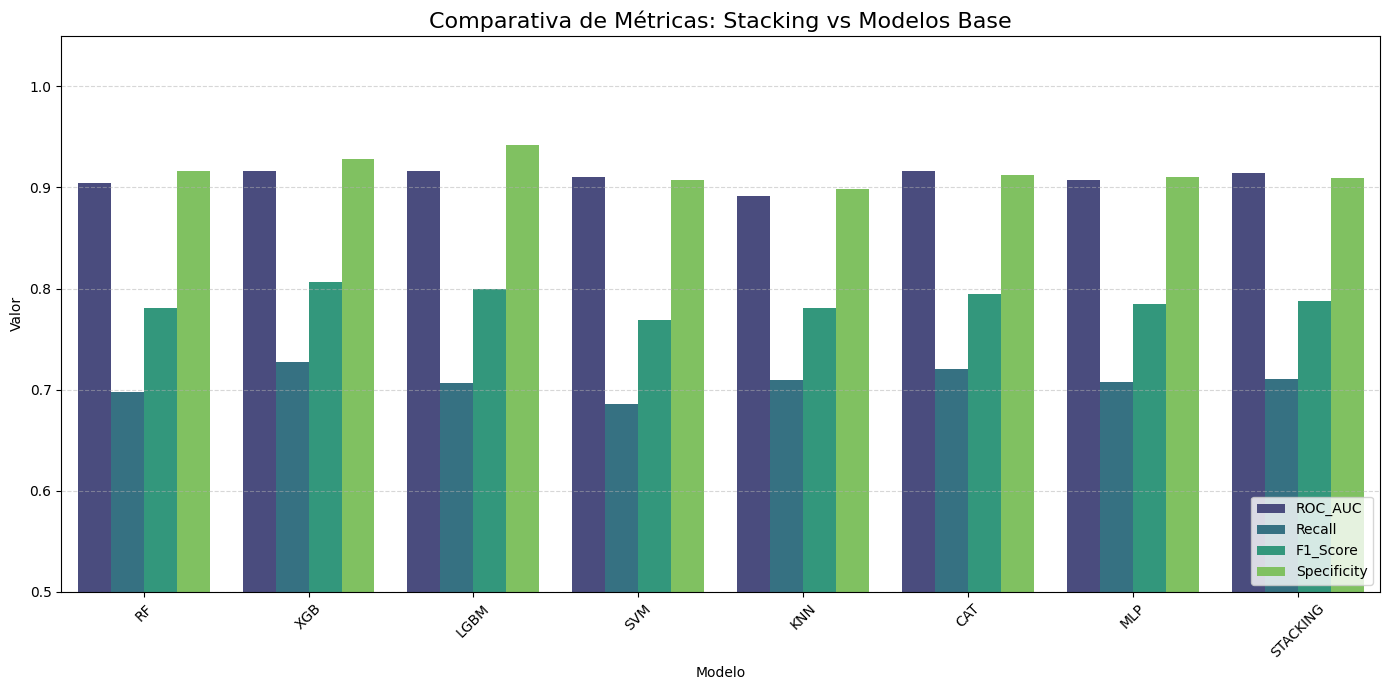

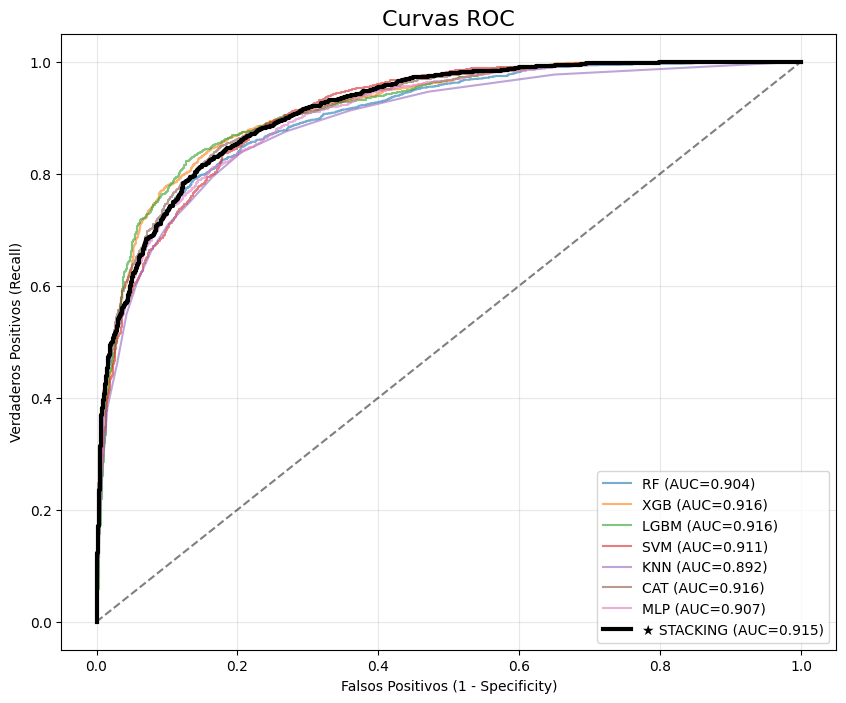

In [36]:
# A. Gráfico de Barras: Métricas Clave
metrics_plot = ['ROC_AUC', 'Recall', 'F1_Score', 'Specificity']
df_plot = df_resultados[metrics_plot].reset_index().melt(id_vars='Modelo', var_name='Métrica', value_name='Valor')

plt.figure(figsize=(14, 7))
sns.barplot(data=df_plot, x='Modelo', y='Valor', hue='Métrica', palette='viridis')
plt.title('Comparativa de Métricas: Stacking vs Modelos Base', fontsize=16)
plt.ylim(0.5, 1.05) # Ajustar zoom si los valores son altos
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# B. Curvas ROC
plt.figure(figsize=(10, 8))
for modelo_name, row in df_resultados.iterrows():
    y_prob = row['y_proba']
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = row['ROC_AUC']
    
    # Destacar Stacking
    if modelo_name == 'STACKING':
        plt.plot(fpr, tpr, label=f"★ {modelo_name} (AUC={auc_val:.3f})", linewidth=3, color='black', zorder=10)
    else:
        plt.plot(fpr, tpr, label=f"{modelo_name} (AUC={auc_val:.3f})", alpha=0.6)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('Falsos Positivos (1 - Specificity)')
plt.ylabel('Verdaderos Positivos (Recall)')
plt.title('Curvas ROC', fontsize=16)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()